In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.metrics import ConfusionMatrixDisplay

from utils import preprocess_data

RANDOM_STATE = 36

# Loading Data

In [60]:
df_train = pd.read_csv('data/train.csv') # With Target
df_test= pd.read_csv('data/test.csv') # No Target
df_train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


# Preprocessing Data

In [61]:
X_train = df_train.drop(columns='Transported')
y_train = df_train['Transported']

X_train, median = preprocess_data(X_train)
X_test, _ = preprocess_data(
    df_test,
    median,
    X_train.columns
)

print(X_train.shape, X_test.shape)
X_test.head()


(8693, 27) (4277, 27)


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,TotalSpendings,HomePlanet_Europa,HomePlanet_Mars,HomePlanet_Unknown,...,CabinDeck_B,CabinDeck_C,CabinDeck_D,CabinDeck_E,CabinDeck_F,CabinDeck_G,CabinDeck_T,CabinDeck_Unknown,CabinSide_S,CabinSide_Unknown
0,27.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
1,19.0,0.0,9.0,0.0,2823.0,0.0,2832.0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
2,31.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0,...,0,1,0,0,0,0,0,0,1,0
3,38.0,0.0,6652.0,0.0,181.0,585.0,7418.0,1,0,0,...,0,1,0,0,0,0,0,0,1,0
4,20.0,10.0,0.0,635.0,0.0,0.0,645.0,0,0,0,...,0,0,0,0,1,0,0,0,1,0


# Train Val Splitting Train Data

In [62]:
X_train, X_cv, y_train, y_cv = train_test_split(X_train, y_train, test_size=0.2, random_state=RANDOM_STATE)
print(X_train.shape, X_cv.shape, y_train.shape, y_cv.shape)

(6954, 27) (1739, 27) (6954,) (1739,)


# Training Tree Model

In [63]:
model = XGBClassifier(
    n_estimators = 500,
    learning_rate = 0.5,
    max_depth = 5,
    subsample = 0.8,
    colsample_bytree =0.5,
    random_state = RANDOM_STATE,
    eval_metric = "logloss",
    early_stopping_rounds=20
)

history = model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_cv, y_cv)],
    verbose=False
)

# Predicting
ypred_train = model.predict(X_train)
ypred_cv = model.predict(X_cv)

# Evaluating Predictions

### Evaluating: Train set Predictions

In [64]:
# accuracy_score_train =  accuracy_score(y_train, ypred_train)
# confusion_matrix_train =  confusion_matrix(y_train, ypred_train)
# classification_report_train =  classification_report(y_train, ypred_train)

# print('Accuracy:', accuracy_score_train)
# print(confusion_matrix_train)
# print(classification_report_train)

### Evaluating: Test set Predictions

In [65]:
accuracy_score_cv =  accuracy_score(y_cv, ypred_cv)
confusion_matrix_cv =  confusion_matrix(y_cv, ypred_cv)
classification_report_cv =  classification_report(y_cv, ypred_cv)

print('Accuracy:', accuracy_score_cv)
print(confusion_matrix_cv)
print(classification_report_cv)


Accuracy: 0.7860839562967222
[[656 191]
 [181 711]]
              precision    recall  f1-score   support

       False       0.78      0.77      0.78       847
        True       0.79      0.80      0.79       892

    accuracy                           0.79      1739
   macro avg       0.79      0.79      0.79      1739
weighted avg       0.79      0.79      0.79      1739



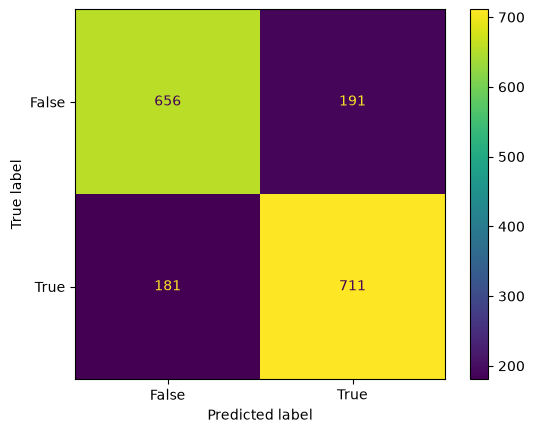

In [66]:
ConfusionMatrixDisplay.from_predictions(y_cv, ypred_cv)
plt.show()

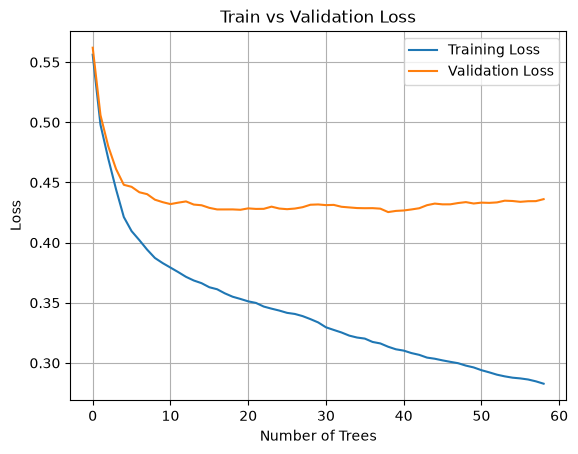

In [67]:
results = model.evals_result()

train_loss = results['validation_0']['logloss']
cv_loss = results['validation_1']['logloss']

plt.plot(train_loss, label='Training Loss')
plt.plot(cv_loss, label='Validation Loss')
plt.title('Train vs Validation Loss')
plt.xlabel('Number of Trees')
plt.ylabel('Loss')
plt.legend()
plt.grid(0.8)